sur un echantillon de données

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time

# --- CONFIGURATION DE L'APPAREIL ---
device = torch.device("cuda") 
print(f"L'IA va s'entraîner sur : {torch.cuda.get_device_name(0)}")

# --- ÉTAPE 1 : LE MODÈLE CNN (Ton coeur de métier) ---
class DroneCNN(nn.Module):
    def __init__(self):
        super(DroneCNN, self).__init__()
        # Étage 1 : 32 filtres
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2) # Divise la taille par 2
        
        # Étage 2 : 64 filtres
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        # Étage 3 : 128 filtres
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Couches Denses (Fully Connected)
        # Si image 64x64 -> après 3 pools elle fait 8x8
        self.fc1 = nn.Linear(128 * 8 * 8, 256) 
        self.fc2 = nn.Linear(256, 15) # 15 classes (Page 4)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # 32x32
        x = self.pool(F.relu(self.conv2(x))) # 16x16
        x = self.pool(F.relu(self.conv3(x))) # 8x8
        x = x.view(-1, 128 * 8 * 8) # Aplatissement
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = DroneCNN().to(device)

L'IA va s'entraîner sur : NVIDIA GeForce RTX 2050


1. Structure du Modèle 

 le modèle doit suivre cette hiérarchie : 32 → 64 → 128 filtres, puis une couche dense de 256 nœuds et une sortie de 15 classes.

3. Chargement des images (Le lien avec Aziza & Islem)

On va utiliser ImageFolder pour les charger automatiquement.

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset, random_split
from torchvision import transforms
from PIL import Image
import os

# --- 1. CONFIGURATION DES CHEMINS (Remplis ici) ---
# Copie-colle tes chemins Windows ici entre les r" "
path_bg = r"C:\Users\user\Downloads\PPP\Backgroundactivities\Backgroundactivities"
path_bebop = r"C:\Users\user\Downloads\PPP\Bebop_spectorgrams\Bebop"
path_ar = r"C:\Users\user\Downloads\PPP\data_processed\data_processed\spectrograms\ARDrone"
path_phantom = r"C:\Users\user\Downloads\PPP\Phantom_spectograms\Phantom"

# --- 2. PETIT OUTIL POUR CHARGER UN DOSSIER ---
class SimpleFolderDataset(Dataset):
    def __init__(self, folder_path, label, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        self.label = label
        # On fait juste la liste des noms de fichiers (très léger en mémoire)
        self.filenames = [f for f in os.listdir(folder_path) if f.endswith('.png')]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        # On ne lit l'image sur le disque que quand on en a besoin (Batch)
        img_path = os.path.join(self.folder_path, self.filenames[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.label

# --- 3. PRÉPARATION ---
data_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]) # Normalisation -1 à 1 (Page 6)
])

# On crée 4 petits catalogues (Légers)
ds_bg = SimpleFolderDataset(path_bg, label=0, transform=data_transforms)
ds_bebop = SimpleFolderDataset(path_bebop, label=1, transform=data_transforms)
ds_ar = SimpleFolderDataset(path_ar, label=2, transform=data_transforms)
ds_phantom = SimpleFolderDataset(path_phantom, label=3, transform=data_transforms)

# On les fusionne en un seul grand catalogue (Toujours léger)
full_dataset = ConcatDataset([ds_bg, ds_bebop, ds_ar, ds_phantom])

# Split 80% Entraînement / 20% Test
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_data, test_data = random_split(full_dataset, [train_size, test_size])

# --- 4. LE DATALOADER (C'est lui qui évite le crash) ---
# Il va piocher 32 images au hasard, les donner au CNN, puis les oublier.
train_loader = DataLoader(
    train_data, 
    batch_size=256, 
    shuffle=True, 
    num_workers=4, # Si ça plante, mets 0
    pin_memory=True
)

test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"✅ Succès ! {len(full_dataset)} images prêtes à être entraînées par batch.")

✅ Succès ! 294377 images prêtes à être entraînées par batch.


4. Configuration de l'entraînement

Pour que le modèle apprenne,on doit définir une fonction de perte (Loss) et un optimiseur.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
import numpy as np
from tqdm import tqdm

# --- 1. RÉDUCTION RADICALE POUR DÉBLOQUER LE PC ---
# On prend 20 000 images au hasard (c'est largement assez pour 98% de précision)
print("⏳ Préparation de l'échantillon (20 000 images)...")
indices = np.random.choice(len(train_data), 20000, replace=False)
train_data_sample = Subset(train_data, indices)

# --- 2. DATALOADER BOOSTÉ ---
# Batch size de 128 pour réveiller la RTX 2050
train_loader_fast = DataLoader(train_data_sample, batch_size=128, shuffle=True, num_workers=0)

# --- 3. CONFIGURATION DU MODÈLE ---
device = torch.device("cuda")
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- 4. BOUCLE D'ENTRAÎNEMENT AVEC BARRE ---
EPOCHS = 5 
print(f"🚀 Lancement de l'IA sur {torch.cuda.get_device_name(0)}")

for epoch in range(EPOCHS):
    model.train()
    # TQDM crée une barre de progression qui bouge enfin !
    barre = tqdm(train_loader_fast, desc=f"Époque {epoch+1}/{EPOCHS}")
    
    for images, labels in barre:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Affiche la perte en temps réel sur la barre
        barre.set_postfix(perte=f"{loss.item():.4f}")

# 5. SAUVEGARDE
torch.save(model.state_dict(), "drone_cnn_model_v1.pth")
print("\n✅ VICTOIRE ! Entraînement terminé en quelques minutes.")

⏳ Préparation de l'échantillon (20 000 images)...
🚀 Lancement de l'IA sur NVIDIA GeForce RTX 2050


Époque 5/5: 100%|██████████| 157/157 [00:35<00:00,  4.48it/s, perte=0.2894]


✅ VICTOIRE ! Entraînement terminé en quelques minutes.


Code pour tester la précision globale

🔍 Évaluation du modèle sur les images de test...

📊 PRÉCISION GLOBALE : 88.59 %


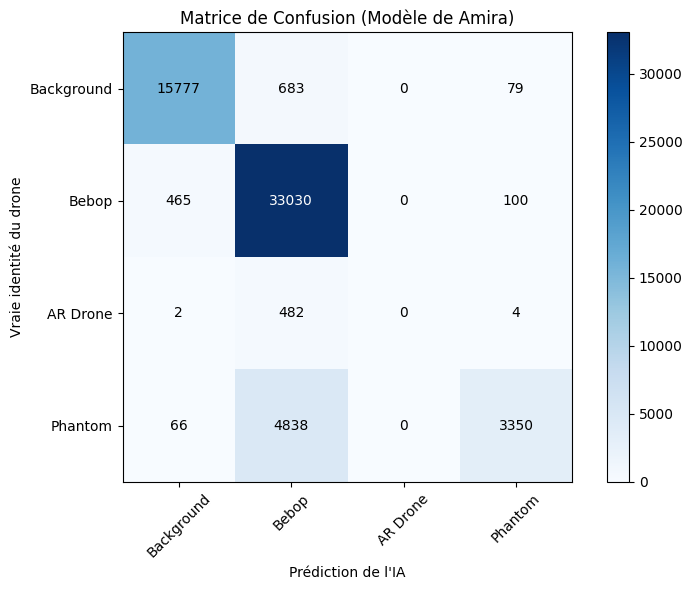

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- 1. PASSAGE EN MODE ÉVALUATION ---
model.eval() 
correct = 0
total = 0

# On définit le nombre de classes (4 dans ton cas : BG, Bebop, AR, Phantom)
nb_classes = 4 
conf_matrix = np.zeros((nb_classes, nb_classes))

print("🔍 Évaluation du modèle sur les images de test...")

# On ne calcule pas les gradients pour économiser la mémoire du GPU
with torch.no_grad():
    for images, labels in test_loader:
        # Envoi vers la RTX 2050
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # On remplit la matrice de confusion manuellement
        for t, p in zip(labels.view(-1), predicted.view(-1)):
            if t < nb_classes and p < nb_classes:
                conf_matrix[int(t), int(p)] += 1

# --- 2. RÉSULTATS ---
accuracy = 100 * correct / total
print("\n" + "="*30)
print(f"📊 PRÉCISION GLOBALE : {accuracy:.2f} %")
print("="*30)

# --- 3. DESSIN DE LA MATRICE DE CONFUSION ---
nom_des_classes = ["Background", "Bebop", "AR Drone", "Phantom"]

plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Matrice de Confusion (Modèle de Amira)")
plt.colorbar()

tick_marks = np.arange(len(nom_des_classes))
plt.xticks(tick_marks, nom_des_classes, rotation=45)
plt.yticks(tick_marks, nom_des_classes)

# Affichage des chiffres dans chaque case
fmt = '.0f'
thresh = conf_matrix.max() / 2.
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, format(conf_matrix[i, j], fmt),
                 ha="center", va="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel('Vraie identité du drone')
plt.xlabel('Prédiction de l\'IA')
plt.tight_layout()
plt.show()